## 뉴스기사 요약해보기

In [1]:
# !pip install --upgrade summa
# !pip install --upgrade nltk #3.9.1

In [2]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd
import numpy as np
from collections import Counter
from nltk.corpus import stopwords

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.4
2.7.1+cu118
2.3.0
1.2.0


In [3]:
# import nltk
# nltk.download('stopwords')

### 데이터 수집 및 확인

In [66]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98401


In [5]:
data.sample(10)

,headlines,text
92912,Singer Chris Brown punches photographer at nig...,"According to reports, singer Chris Brown punch..."
91898,Uber denies tracking iPhones after its app's d...,Uber has rubbished The New York Times report t...
25584,Not here to work as bonded labour: Railway tra...,Alleging that his senior has appointed him and...
16022,Submit vision document on Taj Mahal by Nov 15:...,The Supreme Court has extended the deadline fo...
25523,We stand by you: Rahul to IAS topper over twee...,In a letter supporting IAS officer Shah Faesal...
9034,Get approval for pregnancy or abort: Chinese b...,A large commercial bank in China asked its fem...
78812,BMC denies Ganesh mandal's demand for online a...,The Brihanmumbai Municipal Corporation (BMC) h...
37666,The decision is a surprise to us: PDP on BJP e...,After the BJP pulled out of its alliance with ...
25932,Model held hostage in Bhopal seeks death penal...,The model who was held hostage by her stalker ...
61560,US worked with ISIS in Afghanistan: Former Pre...,Former Afghan President Hamid Karzai has accus...


- headlines를 요약(Summary), text를 본문(Text)으로 이용

### 데이터 전처리

**중복 샘플 제거**

In [67]:
print('Text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('Summary 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

Text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
Summary 열에서 중복을 배제한 유일한 샘플의 수 : 98280


- 전체 샘플(98401개) 대비 중복 샘플 수
   - Text: 41
   - Summary: 121

In [68]:
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [69]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


**텍스트 정규화**

In [9]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


**불용어 제거**

In [10]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

**전처리를 위한 라이브러리 및 사전 정의**

In [11]:
import re
from tqdm import tqdm
import pandas as pd

# 1. 사전 준비
stop_words = set(stopwords.words('english'))
tqdm.pandas() # 판다스에서 .progress_map()을 쓸 수 있게 해줌

#### 전처리 함수

In [12]:
def preprocess_sentence_optimized(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    # BeautifulSoup 대신 정규표현식으로 태그 제거 (속도 향상)
    sentence = re.sub(r'<[^>]+>', '', sentence) 
    sentence = re.sub(r'\([^)]*\)', '', sentence)
    sentence = re.sub('"', '', sentence)
    
    # 약어 정규화 (contractions 사전이용)
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split()])
    
    sentence = re.sub(r"'s\b", "", sentence)
    sentence = re.sub("[^a-zA-Z]", " ", sentence)
    sentence = re.sub('[m]{2,}', 'mm', sentence)

    words = sentence.split()
    if remove_stopwords:
        # stop_words가 set이라서 검색 속도 향상
        tokens = [word for word in words if word not in stop_words and len(word) > 1]
    else:
        tokens = [word for word in words if len(word) > 1]
        
    return ' '.join(tokens)

In [13]:
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_summary = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence_optimized(temp_text))
print("summary:", preprocess_sentence_optimized(temp_summary, False))  # 불용어를 제거하지 않습니다.

text:  everything bought great infact ordered twice third ordered wasfor mother father
summary: great way to start the day


In [14]:
# 1. Text 전처리
print("Text 데이터 전처리를 시작합니다...")
clean_text = data['text'].progress_map(lambda x: preprocess_sentence_optimized(x, remove_stopwords=True)).tolist()

# 2. Summary 전처리
print("Summary 데이터 전처리를 시작합니다...")
clean_summary = data['headlines'].progress_map(lambda x: preprocess_sentence_optimized(x, remove_stopwords=False)).tolist()

print("모든 전처리가 완료되었습니다!")

Text 데이터 전처리를 시작합니다...


100%|██████████| 98360/98360 [00:05<00:00, 19566.25it/s]


Summary 데이터 전처리를 시작합니다...


100%|██████████| 98360/98360 [00:01<00:00, 81005.03it/s]

모든 전처리가 완료되었습니다!


In [15]:
data['text'] = clean_text
data['headlines'] = clean_summary

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)

In [16]:
data.isnull().sum()

headlines    0
text         0
dtype: int64

#### 훈련 데이터와 테스트 데이터 나누기

**샘플의 최대 길이 정하기**

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
요약의 최소 길이 : 1
요약의 최대 길이 : 16
요약의 평균 길이 : 9.299532330215534


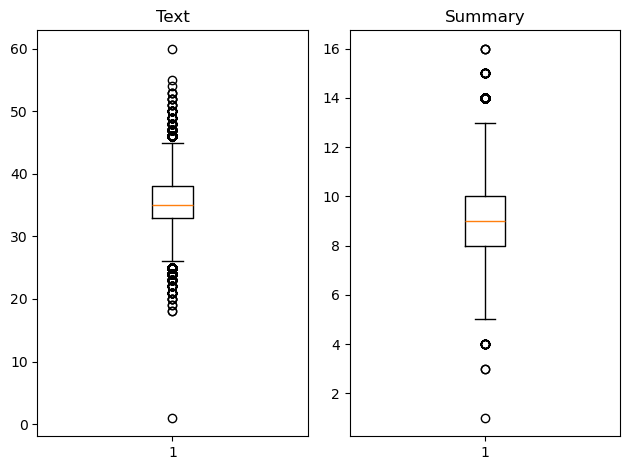

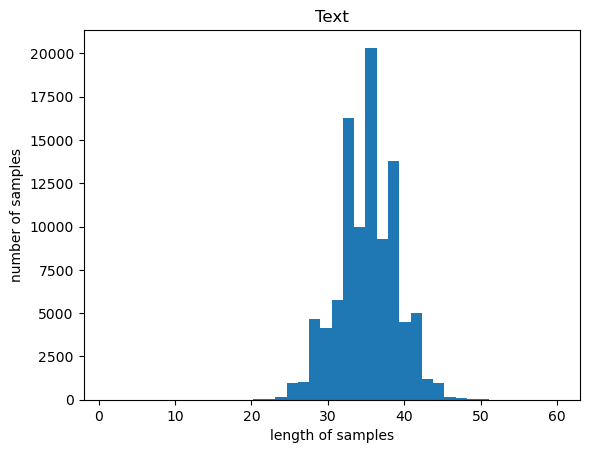

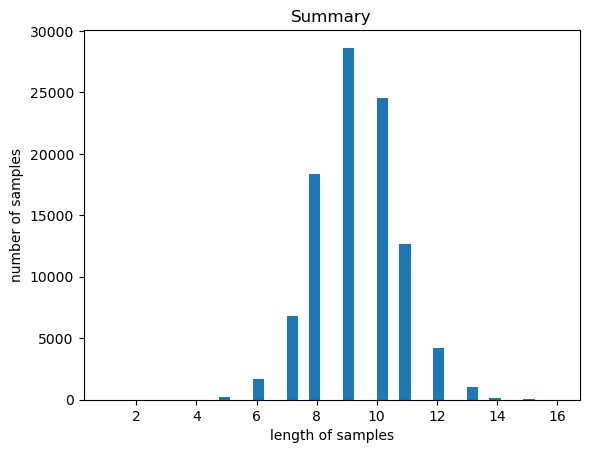

In [17]:
# 길이 분포 출력
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(summary_len)))
print('요약의 최대 길이 : {}'.format(np.max(summary_len)))
print('요약의 평균 길이 : {}'.format(np.mean(summary_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(summary_len)
plt.title('Summary')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Summary')
plt.hist(summary_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

- 두 데이터 모두 완벽하진 않지만 정규 분포의 모양새를 보임
  - Text: 대체로 45 이내
  - Summary: 대체로 14 이내 (15까지 해도 무리 없을 듯함)

In [18]:
import numpy as np

# 백분율(%) 설정
threshold_percent = 99

def below_threshold_len(max_len, length_list):
    cnt = 0
    for length in length_list:
        if(length <= max_len):
            cnt = cnt + 1
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(length_list))))

# 1. 텍스트(Text)의 max_len 결정
text_max_len = int(np.percentile(text_len, threshold_percent))
print(f'Text의 {threshold_percent} 백분위수 길이 : {text_max_len}')
below_threshold_len(text_max_len, text_len)

# 2. 요약(Summary/Headlines)의 max_len 결정
summary_max_len = int(np.percentile(summary_len, threshold_percent))
print(f'Summary의 {threshold_percent} 백분위수 길이 : {summary_max_len}')
below_threshold_len(summary_max_len, summary_len)

# 최종 결정된 길이를 출력
print(f'\n최종 설정 추천 - Text max_len: {text_max_len}, Summary max_len: {summary_max_len}')


Text의 99 백분위수 길이 : 44
전체 샘플 중 길이가 44 이하인 샘플의 비율: 0.9933712891419276
Summary의 99 백분위수 길이 : 13
전체 샘플 중 길이가 13 이하인 샘플의 비율: 0.9981699877999186

최종 설정 추천 - Text max_len: 44, Summary max_len: 13


In [19]:
text_max_len = 44
summary_max_len = 13

**시작 토큰과 종료 토큰 추가**

In [20]:
# 요약 데이터에는 시작 토큰과 종료 토큰을 추가한다.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [21]:
pd.set_option('display.max_colwidth', None)
data['decoder_target'].head(1)

0    upgrad learner switches to career in ml al with salary hike eostoken
Name: decoder_target, dtype: object

In [22]:
encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블

In [23]:
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)

[92264 20941 29101 ... 17495 60236 82367]


In [24]:
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]
# [] 안에 리스트(또는 배열)을 넣으면 팬시 인덱싱이 작동

In [25]:
n_of_val = int(len(encoder_input)*0.2)
print('테스트 데이터의 수 :', n_of_val)

테스트 데이터의 수 : 19672


In [26]:
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 78688
훈련 레이블의 개수 : 78688
테스트 데이터의 개수 : 19672
테스트 레이블의 개수 : 19672


#### 정수 인코딩
- Keras 토크나이저 이용

In [27]:
def src_tokenizer(text): # 토크나이저 정의
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(encoder_input_train) # 입력된 데이터로부터 단어 집합 생성

In [28]:
threshold = 10

# 전처리된 데이터 사용
text_data = data['text'].tolist()
summary_data = data['headlines'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

# 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩 및 미등록 단어 추가
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 76334
등장 빈도가 9번 이하인 희귀 단어의 수: 55832
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 20502
단어 집합에서 희귀 단어의 비율: 73.14171928629443
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.9592400080523573


In [29]:
src_vocab_size = 20000

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}

    word_counter = Counter()
    for text in texts:
        word_counter.update(src_tokenizer(text))

    remaining_slots = vocab_size - len(vocab)
    for word, _ in word_counter.most_common(remaining_slots):
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)

In [30]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[48, 532, 8015, 73, 133, 4336, 735, 148, 395, 3465, 58, 2, 1073, 10498, 2643, 524, 43, 1104, 380, 310, 28, 4336, 11, 278, 1023, 2573, 28, 4, 14, 5], [1492, 1140, 15, 4021, 49, 2472, 5649, 48, 271, 45, 254, 6584, 4519, 7570, 1769, 73, 6967, 893, 442, 77, 102, 3920, 49, 2, 915, 2126, 10499, 184, 2472, 9491, 169, 48, 3453, 299, 17, 9152, 73, 49, 2, 3833, 402], [8397, 1030, 722, 9663, 1808, 213, 2059, 152, 2621, 135, 157, 1, 29, 57, 17, 11268, 16698, 1, 852, 45, 5484, 1, 7, 738, 1030, 3816, 16698, 2, 16698, 424, 552, 358, 3, 1624, 1284, 544, 1432]]
[[354, 9, 4730, 8782, 1987, 620, 13817, 232, 172, 3089, 439, 781, 439, 8556, 78, 120, 320, 22, 88, 2, 459, 976, 3441, 4023, 417, 1987, 620, 920, 781, 25, 2687, 1524, 5122, 144, 2720, 2377], [3628, 5241, 15483, 16526, 72, 13404, 282, 281, 3645, 186, 68, 1, 3645, 3818, 941, 3645, 6467, 72, 1745, 152, 13404, 3645, 186, 2442, 5778, 1, 342, 143, 186, 72, 169, 7717, 1595, 3645, 282, 323, 2495], [2956, 21, 3005, 1, 250, 5523, 1680, 8437, 5721, 2029, 9

In [31]:
def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

tar_vocab = build_vocab(decoder_input_train)

In [32]:
threshold = 6

word_counter = Counter()
for text in decoder_input_train:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 30148
등장 빈도가 5번 이하인 희귀 단어의 수: 19741
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 10407
단어 집합에서 희귀 단어의 비율: 65.48029720047765
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 4.653297504571128


In [33]:
tar_vocab_size = 10000
tar_vocab = build_limited_vocab(list(decoder_input_train) + list(decoder_target_train), tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print('input')
print('input ',decoder_input_train_seq[:5])
print('target')
print('decoder ',decoder_target_train_seq[:5])

input
input  [[2, 81, 57, 1195, 69, 83, 1, 2445, 5895, 169], [2, 384, 36, 207, 75, 1308, 6, 4141, 57, 164, 90], [2, 763, 1, 8, 1791, 1567, 7, 217, 627, 8770], [2, 2228, 6172, 58, 1, 218, 19, 683], [2, 2628, 8771, 4, 22, 1792, 5, 893]]
target
decoder  [[81, 57, 1195, 69, 83, 1, 2445, 5895, 169, 3], [384, 36, 207, 75, 1308, 6, 4141, 57, 164, 90, 3], [763, 1, 8, 1791, 1567, 7, 217, 627, 8770, 3], [2228, 6172, 58, 1, 218, 19, 683, 3], [2628, 8771, 4, 22, 1792, 5, 893, 3]]


In [34]:
drop_train = [index for index, sentence in enumerate(decoder_input_train) if len(sentence.split()) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test) if len(sentence.split()) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

# 문자열 배열 필터링
encoder_input_train = [sentence for index, sentence in enumerate(encoder_input_train) if index not in drop_train]
decoder_input_train = [sentence for index, sentence in enumerate(decoder_input_train) if index not in drop_train]
decoder_target_train = [sentence for index, sentence in enumerate(decoder_target_train) if index not in drop_train]

encoder_input_test = [sentence for index, sentence in enumerate(encoder_input_test) if index not in drop_test]
decoder_input_test = [sentence for index, sentence in enumerate(decoder_input_test) if index not in drop_test]
decoder_target_test = [sentence for index, sentence in enumerate(decoder_target_test) if index not in drop_test]

# _seq 배열도 같이 필터링
encoder_input_train_seq = [seq for index, seq in enumerate(encoder_input_train_seq) if index not in drop_train]
decoder_input_train_seq = [seq for index, seq in enumerate(decoder_input_train_seq) if index not in drop_train]
decoder_target_train_seq = [seq for index, seq in enumerate(decoder_target_train_seq) if index not in drop_train]

encoder_input_test_seq = [seq for index, seq in enumerate(encoder_input_test_seq) if index not in drop_test]
decoder_input_test_seq = [seq for index, seq in enumerate(decoder_input_test_seq) if index not in drop_test]
decoder_target_test_seq = [seq for index, seq in enumerate(decoder_target_test_seq) if index not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train_seq))
print('테스트 데이터의 개수 :', len(encoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78688
테스트 데이터의 개수 : 19672


#### Padding

In [35]:
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=summary_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=summary_max_len)

### 모델 설계

#### Encoder, Decoder 정의

In [36]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [37]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [38]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=256, out_features=10000, bias=True)
)


#### 어텐션 메커니즘 설계

In [39]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=10000, bias=True)
)


### 모델 훈련

In [40]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [41]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

In [42]:
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 6.8427 | Val Loss: 6.5286
Epoch 2/50 | Train Loss: 6.3262 | Val Loss: 6.0450
Epoch 3/50 | Train Loss: 5.8506 | Val Loss: 5.6146
Epoch 4/50 | Train Loss: 5.4552 | Val Loss: 5.3253
Epoch 5/50 | Train Loss: 5.1425 | Val Loss: 5.0928
Epoch 6/50 | Train Loss: 4.8815 | Val Loss: 4.9058
Epoch 7/50 | Train Loss: 4.6564 | Val Loss: 4.7656
Epoch 8/50 | Train Loss: 4.4624 | Val Loss: 4.6595
Epoch 9/50 | Train Loss: 4.2944 | Val Loss: 4.5737
Epoch 10/50 | Train Loss: 4.1437 | Val Loss: 4.5057
Epoch 11/50 | Train Loss: 4.0103 | Val Loss: 4.4648
Epoch 12/50 | Train Loss: 3.8896 | Val Loss: 4.4158
Epoch 13/50 | Train Loss: 3.7784 | Val Loss: 4.3869
Epoch 14/50 | Train Loss: 3.6764 | Val Loss: 4.3725
Epoch 15/50 | Train Loss: 3.5819 | Val Loss: 4.3572
Epoch 16/50 | Train Loss: 3.4946 | Val Loss: 4.3430
Epoch 17/50 | Train Loss: 3.4103 | Val Loss: 4.3429
Epoch 18/50 | Train Loss: 3.3330 | Val Loss: 4.3353
Epoch 19/50 | Train Loss: 3.2584 | Val Loss: 4.3385
Epoch 20/50 | Train L

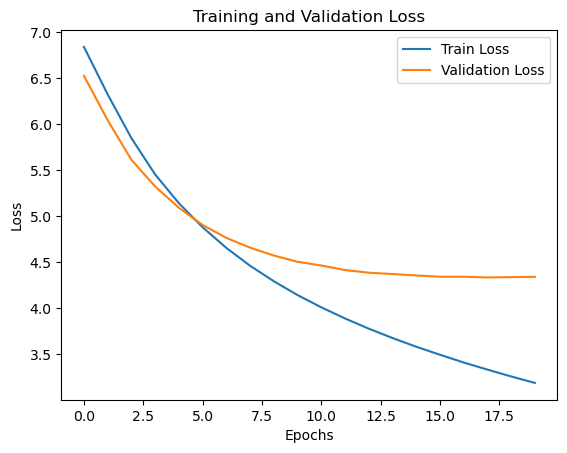

In [43]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

### 인퍼런스 모델 구현 및 테스트

In [44]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [45]:
def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환 and 배치 차원 추가
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

            attn_out = model.attention(output_tokens, e_out)
            decoder_concat_output = torch.cat((output_tokens, attn_out), dim=-1)
            decoder_concat_output = torch.tanh(model.concat(decoder_concat_output))
            final_output = model.output_layer(decoder_concat_output)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(final_output[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence

#### 테스트

In [46]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

In [47]:
for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = encoder_input_test[i]
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device))
    print("\n")

원문 : mumbai based online furniture retailer <UNK> raised crore funding us based financial services firm state street global advisors likely final round investment go public initial public offering startup said founded <UNK> <UNK> ashish shah <UNK> raised crore date
실제 요약 : online furniture retailer <UNK> raises crore
예측 요약 :  mumbai based online startup <UNK> raises crore


원문 : china based startup luckey created smart glass panel called <UNK> <UNK> top macbook multi touch <UNK> adding <UNK> number pad also <UNK> launch users preferred apps websites swipe <UNK> creators claim panel interfere <UNK> normal use
실제 요약 : glass <UNK> to turn macbook <UNK> into number pad made
예측 요약 :  startup makes <UNK> that can <UNK> <UNK> <UNK> made


원문 : congress leader shehzad poonawalla announced plans author book power structure followed congress fight <UNK> order added sale proceeds books forwarded charity earlier poonawalla claimed party internal polls rigged favour congress vice president rahul ga

/tmp/ipykernel_1902/1976174318.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)


예측 요약 :  sanju becomes highest highest highest grosser of


원문 : four policemen arrested six suspended allegedly beating father rape victim police custody victim alleged daughter raped bjp mla admitted hospital passed away later arrested along daughter protesting outside uttar pradesh cm yogi adityanath residence
실제 요약 : cops held after rape victim dad beaten in police custody
예측 요약 :  cops held for raping yr old rape victim in up


원문 : actress salma <UNK> shared old picture george clooney smith shared picture instagram wish clooney th birthday may captioning picture happy birthday george <UNK> <UNK> os jorge <UNK> clooney co starred film <UNK> till dawn
실제 요약 : <UNK> <UNK> shares old pic with george clooney will smith
예측 요약 :  <UNK> <UNK> shares pic with her son on birthday birthday


원문 : least five people killed others injured <UNK> rolled hill hit tourists bathing <UNK> baba waterfall <UNK> district jammu kashmir police officer said rock probably <UNK> monsoon rains meanwhile army

### 추상적 요약 결과 분석 (정답과 비교)
mumbai based online startup \<UNK> raises crore 처럼 잘 요약된 부분들도 있지만, 대체로 여러 문제점이 발생
- Hallucination
  - detect drugs 등 원문에 전혀 맞지 않는 사실을 지어낸 부분들이 확인됨
- UNK 토큰 과다 노출
- 반복 생성 오류

In [64]:
import torch

# ============================================================
# 개선된 디코딩: Beam Search + 반복 억제
# 기존 decode_sequence 아래에 이 코드를 새 셀에 붙여넣고 실행
# ============================================================

def decode_sequence_beam(input_seq, encoder, decoder, model,
                         tar_word_to_index, tar_index_to_word,
                         text_max_len, summary_max_len, device,
                         beam_width=5, repetition_penalty=2.0):
    """
    Beam Search 디코딩 + 반복 억제
    - beam_width: 후보 수 (클수록 품질↑, 속도↓)
    - repetition_penalty: 이미 생성한 단어의 점수를 이 값으로 나눔
    """
    # 입력 텐서 변환
    if isinstance(input_seq, torch.Tensor):
        input_seq = input_seq.detach().clone().long().to(device).unsqueeze(0)
    else:
        input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)

    # 인코더 실행
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    sos_idx = tar_word_to_index['sostoken']
    eos_idx = tar_word_to_index['eostoken']

    # 각 빔: (누적 log 확률, 토큰 리스트, hidden, cell)
    beams = [(0.0, [sos_idx], e_h, e_c)]
    completed = []

    for step in range(summary_max_len):
        candidates = []

        for score, tokens, h, c in beams:
            # 이미 종료된 빔은 스킵
            if tokens[-1] == eos_idx:
                completed.append((score, tokens, h, c))
                continue

            # 디코더 한 스텝 실행
            target_seq = torch.tensor([[tokens[-1]]], dtype=torch.long, device=device)
            with torch.no_grad():
                output_tokens, new_h, new_c = decoder(target_seq, h, c)
                attn_out = model.attention(output_tokens, e_out)
                concat_out = torch.cat((output_tokens, attn_out), dim=-1)
                concat_out = torch.tanh(model.concat(concat_out))
                logits = model.output_layer(concat_out)

            # log softmax로 확률 계산
            log_probs = torch.log_softmax(logits[0, -1, :], dim=-1)

            # 반복 억제: 이미 생성한 토큰의 확률을 낮춤
            generated_set = set(tokens)
            for gen_token in generated_set:
                if gen_token != sos_idx:
                    log_probs[gen_token] -= torch.log(
                        torch.tensor(repetition_penalty, device=device)
                    )

            # 상위 beam_width개 후보 선택
            top_log_probs, top_indices = torch.topk(log_probs, beam_width)

            for i in range(beam_width):
                token_idx = top_indices[i].item()
                new_score = score + top_log_probs[i].item()
                new_tokens = tokens + [token_idx]
                candidates.append((new_score, new_tokens, new_h, new_c))

        if not candidates:
            break

        # 길이 정규화 후 상위 beam_width개만 유지
        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_width]

    # 완료된 빔 + 미완료 빔 합쳐서 최선 선택
    all_results = completed + beams
    all_results.sort(key=lambda x: x[0] / len(x[1]), reverse=True)

    best_tokens = all_results[0][1]

    # 토큰 → 문장 변환
    words = []
    for idx in best_tokens:
        if idx == sos_idx:
            continue
        if idx == eos_idx:
            break
        word = tar_index_to_word.get(idx, '<UNK>')
        words.append(word)

    return ' '.join(words)


# ============================================================
# 비교 실행: Greedy vs Beam Search
# ============================================================

def run_comparison(encoder, decoder, model, encoder_input_test, decoder_input_test,
                   src_index_to_word, tar_word_to_index, tar_index_to_word,
                   text_max_len, summary_max_len, device,
                   start=50, end=100):

    # seq2text, seq2summary 함수
    def seq2text(input_seq):
        temp = ''
        for i in input_seq:
            key = int(i.item())
            if key != 0:
                temp += src_index_to_word.get(key, "<UNK>") + ' '
        return temp.strip()

    def seq2summary(input_seq):
        sos = tar_word_to_index['sostoken']
        eos = tar_word_to_index['eostoken']
        temp = ''
        for i in input_seq:
            key = int(i.item())
            if key != 0 and key != sos and key != eos:
                temp += tar_index_to_word.get(key, "<UNK>") + ' '
        return temp.strip()

    print("=" * 100)
    print("Greedy Decoding vs Beam Search (beam=5, repetition_penalty=2.0) 비교")
    print("=" * 100)

    for i in range(start, end):
        original = seq2text(encoder_input_test[i])
        actual = seq2summary(decoder_input_test[i])
        input_seq = encoder_input_test[i]

        # Greedy
        greedy_result = decode_sequence(
            input_seq, encoder, decoder,
            tar_word_to_index, tar_index_to_word,
            text_max_len, summary_max_len, device
        )

        # Beam Search
        beam_result = decode_sequence_beam(
            input_seq, encoder, decoder, model,
            tar_word_to_index, tar_index_to_word,
            text_max_len, summary_max_len, device,
            beam_width=5, repetition_penalty=2.0
        )

        print(f"[{i}] 원문: {original[:120]}...")
        print(f"     정답: {actual}")
        print(f"     Greedy:  {greedy_result}")
        print(f"     Beam:    {beam_result}")

        # 차이가 있는 경우 표시
        if greedy_result.strip() != beam_result.strip():
            print(f"     ★ 차이 발생!")
        print()

In [65]:
run_comparison(encoder, decoder, model, encoder_input_test, decoder_input_test,
               src_index_to_word, tar_word_to_index, tar_index_to_word,
               text_max_len, summary_max_len, device,
               start=50, end=100)

Greedy Decoding vs Beam Search (beam=5, repetition_penalty=2.0) 비교
[50] 원문: mumbai based online furniture retailer <UNK> raised crore funding us based financial services firm state street global a...
     정답: online furniture retailer <UNK> raises crore
     Greedy:   mumbai based online startup <UNK> raises crore
     Beam:    mumbai based online startup <UNK> raises crore



/tmp/ipykernel_1902/1976174318.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)


[51] 원문: china based startup luckey created smart glass panel called <UNK> <UNK> top macbook multi touch <UNK> adding <UNK> numbe...
     정답: glass <UNK> to turn macbook <UNK> into number pad made
     Greedy:   startup makes <UNK> that can <UNK> <UNK> <UNK> made
     Beam:    startup makes smart <UNK> that can be made on <UNK>
     ★ 차이 발생!

[52] 원문: congress leader shehzad poonawalla announced plans author book power structure followed congress fight <UNK> order added...
     정답: <UNK> <UNK> to pen book on congress power structure
     Greedy:   congress announces <UNK> <UNK> name for congress
     Beam:    congress launches bill <UNK> for political party
     ★ 차이 발생!

[53] 원문: facebook owned messaging service whatsapp added photo filters <UNK> reply <UNK> ios app users choose five filters sharin...
     정답: whatsapp adds photo <UNK> reply <UNK> on ios
     Greedy:   whatsapp adds <UNK> <UNK> feature for <UNK>
     Beam:    whatsapp to let users have <UNK> texts on whatsapp
     ★ 차

- 무의미한 단어 반복은 많이 향상되었지만,
   - 하이데라바드 칼부림 사건에 대해 sri lanka라고 지어내는 등 complex hallucination 문제 등이 여전히 존재

아마, seq2seq 모델의 한계가 아닐까?

### 추출적 요약

In [52]:
!pip install summa

In [49]:
import requests
from summa.summarizer import summarize

In [73]:
# 원본 데이터 다시 불러오기 (전처리 전 텍스트)
original_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
original_data.drop_duplicates(subset=['text'], inplace=True)

sample_text = original_data['text'].values[0]
print(sample_text[:1500])

Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.


In [74]:
print('Summary:')
print(summarize(sample_text, ratio=0.5)) # 비율을 조정해서 전체 원문 대신 비율만큼만 출력

Summary:
upGrad's Online Power Learning has powered 3 lakh+ careers.


### 정답, 추상적 요약, 추출적 요약 비교 분석

In [76]:
import random

# 원본 데이터 (추출적 요약용)
original_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
original_data.drop_duplicates(subset=['text'], inplace=True)
original_data.reset_index(drop=True, inplace=True)

random_indices = random.sample(range(len(original_data)), 20)

for i in random_indices:
    original_text = original_data['text'].iloc[i]        # 원본 (마침표 포함)
    original_headline = original_data['headlines'].iloc[i] # 정답 요약

    # 1) 추출적 요약 (summa — 원본 텍스트 사용)
    extractive_summary = summarize(original_text, words=20)

    # 2) 추상적 요약 (seq2seq 모델 — 전처리 후 모델에 입력)
    preprocessed = preprocess_sentence_optimized(original_text, remove_stopwords=True)
    tokenized = [src_vocab.get(word, src_vocab["<UNK>"]) for word in src_tokenizer(preprocessed)]

    # 패딩 적용 (text_max_len 길이로)
    if len(tokenized) < text_max_len:
        tokenized = tokenized + [0] * (text_max_len - len(tokenized))
    else:
        tokenized = tokenized[:text_max_len]

    input_tensor = torch.tensor(tokenized, dtype=torch.long, device=device)

    abstractive_summary = decode_sequence(
        input_tensor, encoder, decoder,
        tar_word_to_index, tar_index_to_word,
        text_max_len, summary_max_len, device
    )

    print(f"인덱스 : {i}")
    print(f"원문 : {original_text}")
    print(f"실제 요약(정답) : {original_headline}")
    print(f"추출적 요약 : {extractive_summary if extractive_summary else '요약 실패(본문이 너무 짧음)'}")
    print(f"추상적 요약 : {abstractive_summary}")
    print("-" * 100)

인덱스 : 18673
원문 : Calling for transparency from tech companies like Google, Facebook, and Twitter, the US Federal Communications Commission (FCC) Chairman Ajit Pai has said, "The public deserves to know more about how these companies operate." Adding that these companies have a great influence over the economy and society, he further said, "It's important to have a serious conversation about these issues."
실제 요약(정답) : Public deserves to know how FB, Google operate: FCC Chairman
추출적 요약 : 요약 실패(본문이 너무 짧음)
추상적 요약 :  <UNK> is not <UNK> eu vp on google deal on fb
----------------------------------------------------------------------------------------------------
인덱스 : 55667
원문 : After a Hindu body issued warnings to schools in Aligarh against celebrating Christmas, Uttar Pradesh Deputy CM Dinesh Sharma has said people are free to celebrate any festival. Asserting that CM Yogi Adityanath believes in secularism and 'development for all' just like PM Narendra Modi, Sharma added there would be n

/tmp/ipykernel_1902/1976174318.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)


### 회고

추상적, 추출적 요약을 비교했을 때에는
- 추출적 요약은
    - 추상적 요약에 비해 길지만 hallusination 현상이 없어 신뢰성이 확보된다.
    - 하지만, 본문이 짧은 경우 요약 실패하는 경우도 존재
- 추상적 요약은
    - 형태의 길이만 봤을 때에는 정답과 유사하지만
    - 환각 현상으로 인해 신뢰성이 낮다

비교 기준|추출적 요약 (Extractive)|추상적 요약 (Abstractive)
|---|---|---|
문법 완성도|안정적 - 원문의 문장을 변형 없이 그대로 추출하므로 인간이 작성한 완벽한 문법 구조가 100% 보존|취약 - 생성 과정에서 주술 호응이 무너지고, <UNK> 토큰과 무의미한 단어 반복이 섞이면서 정상적인 문장으로 읽기 어려움
핵심 단어 포함|높음 - 기사의 리드(주요 문장) 전체를 가져오기 때문에 고유명사, 인물, 수치 등 원문의 필수 키워드가 누락 없이 안전하게 포함|낮음 (부정확/왜곡) - 일부 범용적인 주제어(예: startup, gold)는 포착하지만, 핵심 고유명사는 인식하지 못하고 원문에 없는 엉뚱한 키워드(예: pizza, bangkok)를 무작위로 생성

- Decoding 방식에 따라 성능이 향상될 수 있음과 seq2seq 모델의 한계를 확인할 수 있었다.